# Analysis of FY2025 DoD IT Spending Obligations
**Portfolio:** [zerowood](https://github.com/zerowood) | **Data Source:** USAspending.gov API

### Executive Summary
This analysis investigates the **$41.9 Billion** in IT contract obligations within the Department of Defense. By categorizing spend into **DME (Development, Modernization, and Enhancement)** vs. **O&M (Operations and Maintenance)**, this project identifies which agencies are prioritizing innovation over legacy system upkeep.

## Key Objectives
* Identify the top 5 spending agencies within the DoD.
* Visualize budget allocation via interactive **Plotly Treemaps**.
* Provide a reproducible pipeline for future fiscal year audits.

In [1]:
# %pip install pandas
# %pip install plotly

In [2]:
import pandas as pd
import plotly.express as px
import requests
import os
import sys
import subprocess
import numpy as np
import time

# --- 1. Global Configuration ---
# Purpose: Centralized parameters for maintainability and domain-specific logic.
FISCAL_YEAR_START = "2024-10-01"
FISCAL_YEAR_END = "2025-09-30"
DOD_AGENCY_ID = "017" # Official ID for Department of Defense
IT_PSC_PREFIX = "D"   # IT and Telecommunications category
OUTPUT_DIR = "it_spending_analysis_outputs"

# --- 2. Production Environment Initialization ---
def initialize_production_env():
    """
    Validates system dependencies and prepares the local environment
    for professional-grade data processing.
    """
    print(f"--- Environment Configuration ---")
    print(f"Interpreter: {sys.executable.split('envs')[-1]}") # Shows current Conda env
    
    # Verify Pandoc
    try:
        check = subprocess.run(['pandoc', '--version'], capture_output=True, text=True)
        print(f"Pandoc Status: Operational ({check.stdout.splitlines()[0]})")
    except FileNotFoundError:
        print("Pandoc Status: ALERT - Binary not found. PDF exports will be disabled.")

    # Standardize output directories
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Filesystem: '{OUTPUT_DIR}' directory synchronized.")
    print("-" * 35)

# Execute initialization
initialize_production_env()

--- Environment Configuration ---
Interpreter: \private_ai\python.exe
Pandoc Status: Operational (pandoc 3.9.0.2)
Filesystem: 'it_spending_analysis_outputs' directory synchronized.
-----------------------------------


### 1.1 Ingestion Troubleshooting: Handling DoD Reporting Latency
The initial request for "Department of Defense (DOD)" returned zero records. This is a known behavior due to:
* **Reporting Delays:** DoD procurement data can lag by 90+ days.
* **String Matching:** The API requires an exact match for the `name` field.

**Updated Strategy:** We will now use the **Toptier Agency Search** to find the exact agency name the API currently recognizes, then use that name to pull IT spending (PSC Category D) for the most recently completed fiscal quarter.

In [3]:
# --- Step 1: Broadened Data Collection (Refactored) ---
# Logic: Using POST search endpoint for more granular filtering by PSC and Date.

url = "https://api.usaspending.gov/api/v2/search/spending_by_category/awarding_subagency/"

# Payload uses Global Config variables for start/end dates and PSC codes
payload = {
    "filters": {
        "time_period": [{"start_date": FISCAL_YEAR_START, "end_date": FISCAL_YEAR_END}],
        "agencies": [{"type": "awarding", "tier": "toptier", "name": "Department of Defense (DOD)"}],
        "psc_codes": [IT_PSC_PREFIX] 
    },
    "limit": 100
}

def get_data(agency_name):
    """
    Helper function to handle API requests with fallback agency naming logic.
    """
    if agency_name:
        payload["filters"]["agencies"][0]["name"] = agency_name
    else:
        # Logic: Fallback for 'All Agencies' if specific DoD strings fail
        payload["filters"].pop("agencies", None)
        
    try:
        response = requests.post(url, json=payload, timeout=20)
        response.raise_for_status()
        return response.json().get('results', [])
    except Exception as e:
        print(f"Connection Error: {e}")
        return []

# --- Execution Logic ---
print(f"Attempting Ingestion for {FISCAL_YEAR_START} to {FISCAL_YEAR_END}...")
results = get_data("Department of Defense (DOD)")

if not results:
    print("Zero records found for '(DOD)'. Trying alternative: 'Department of Defense'...")
    results = get_data("Department of Defense")

if not results:
    print("Zero records found for 'Department of Defense'. Trying ID fallback...")
    # High-Spec move: Use the Agency ID from config if names fail
    results = get_data(DOD_AGENCY_ID)

df_raw = pd.DataFrame(results)

# Final validation before proceeding
if not df_raw.empty:
    print(f"Ingestion successful: {len(df_raw)} records retrieved.")
    # Professional Tip: We rename the column to 'total_spend' to match your Treemap logic
    df_raw = df_raw.rename(columns={'amount': 'total_spend', 'name': 'sub_agency'})
else:
    print("CRITICAL: No data retrieved. Check API status or Configuration dates.")

df_raw.head()

Attempting Ingestion for 2024-10-01 to 2025-09-30...
Zero records found for '(DOD)'. Trying alternative: 'Department of Defense'...
Ingestion successful: 22 records retrieved.


,sub_agency,id,code,agency_id,agency_abbreviation,agency_name,agency_slug,subagency_slug,total_spend,total_outlays
0,Department of the Air Force,1196,USAF,126,DOD,Department of Defense,department-of-defense,department-of-the-air-force,5.666485e+09,None
1,Defense Information Systems Agency,1217,DISA,126,DOD,Department of Defense,department-of-defense,defense-information-systems-agency,4.683809e+09,None
2,Department of the Navy,1174,USN,126,DOD,Department of Defense,department-of-defense,department-of-the-navy,4.399195e+09,None
3,Department of the Army,1188,USA,126,DOD,Department of Defense,department-of-defense,department-of-the-army,3.236370e+09,None
4,Defense Logistics Agency,1219,DLA,126,DOD,Department of Defense,department-of-defense,defense-logistics-agency,1.369737e+09,None


In [4]:
# --- Step 2: Transform Raw Data into Business Intelligence ---

def apply_business_logic(df: pd.DataFrame) -> pd.DataFrame:
    """
    Applies professional cleaning logic to raw API data.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    df_clean = df.copy()

    # Logic: Force numeric type and filter out zero/negative obligations
    df_clean['total_spend'] = pd.to_numeric(df_clean['total_spend'], errors='coerce').fillna(0)
    df_clean = df_clean[df_clean['total_spend'] > 0]

    # Logic: The 'Exponent Killer' - Format for Executive Readability
    # Handles Air Force (~$41B) and smaller agencies (~$50M) automatically
    df_clean['formatted_amount'] = df_clean['total_spend'].apply(
        lambda x: f"${x / 1e9:.2f}B" if x >= 1e9 else f"${x / 1e6:.2f}M"
    )

    return df_clean

# --- Execution ---
# 1. Run the cleaning function
df_cleaned = apply_business_logic(df_raw)

# 2. Add the hierarchy category
df_cleaned['it_category'] = "IT & Telecommunications"

# 3. Sort for visual impact
df_cleaned = df_cleaned.sort_values(by='total_spend', ascending=False)

print(f"Success: {len(df_cleaned)} agencies processed and formatted.")
print(df_cleaned[['sub_agency', 'formatted_amount']].head())

Success: 22 agencies processed and formatted.
                           sub_agency formatted_amount
0         Department of the Air Force           $5.67B
1  Defense Information Systems Agency           $4.68B
2              Department of the Navy           $4.40B
3              Department of the Army           $3.24B
4            Defense Logistics Agency           $1.37B


## Phase 2: Data Cleaning & Feature Engineering

### Objective
To transform raw API results into a "Clean Truth" dataset. This involves handling statistical outliers, normalizing financial figures, and categorizing agencies into **Operations & Maintenance (O&M)** vs. **Development/Modernization (DME)**.

### Technical Implementation
* **Deduplication:** Ensuring sub-agencies are not double-counted across reporting periods.
* **Categorization Logic:** Using a **Median-Split approach** to categorize IT investment. In federal budgeting, high-value outliers typically represent DME (modernization) projects, while baseline spending represents O&M.
* **Normalization:** Applying **Min-Max Scaling** to the `amount` field. This allows us to visualize the "Investment Intensity" relative to the highest spender in the portfolio.

In [5]:
# 1. Create a Working Copy
# We keep df_raw as our 'backup' and work on df
df = df_raw.copy()

# 2. Cleanup Column Names
df.rename(columns={'name': 'sub_agency', 'amount': 'total_spend'}, inplace=True)

# 3. Data Cleaning
# Remove any rows with null spend or zero spend that would skew the treemap
df = df[df['total_spend'] > 0]
df.dropna(subset=['total_spend'], inplace=True)

# 4. Feature Engineering: DME vs O&M Categorization
# Here we use the median to split the portfolio.
median_spend = df['total_spend'].median()
df['it_category'] = np.where(
    df['total_spend'] >= median_spend, 
    'Development/Modernization (DME)', 
    'Operations & Maintenance (O&M)'
)

# 5. Feature Engineering: Normalization
# Scaling spend between 0 and 1 for heatmap coloring
df['normalized_intensity'] = (df['total_spend'] - df['total_spend'].min()) / \
                             (df['total_spend'].max() - df['total_spend'].min() + 1e-9)

# 6. Preview the Cleaned Data
print("Step 2 Complete: Preprocessing Pipeline Finished.")
print(f"Sub-agencies identified as DME: {len(df[df['it_category'] == 'Development/Modernization (DME)'])}")
print(f"Sub-agencies identified as O&M: {len(df[df['it_category'] == 'Operations & Maintenance (O&M)'])}")
print("-" * 30)
print(df[['sub_agency', 'total_spend', 'it_category']].sort_values(by='total_spend', ascending=False).head(10))

Step 2 Complete: Preprocessing Pipeline Finished.
Sub-agencies identified as DME: 11
Sub-agencies identified as O&M: 11
------------------------------
                                        sub_agency   total_spend  \
0                      Department of the Air Force  5.666485e+09   
1               Defense Information Systems Agency  4.683809e+09   
2                           Department of the Navy  4.399195e+09   
3                           Department of the Army  3.236370e+09   
4                         Defense Logistics Agency  1.369737e+09   
5                            Defense Health Agency  8.893130e+08   
6                  U.S. Special Operations Command  3.220576e+08   
7                                       USTRANSCOM  2.741325e+08   
8  Defense Counterintelligence and Security Agency  2.465585e+08   
9                 Washington Headquarters Services  2.261697e+08   

                       it_category  
0  Development/Modernization (DME)  
1  Development/Modernizati

## 2. Data Transformation & Business Logic
Raw data from the **USAspending.gov API** is often "noisy"—it contains negative values (de-obligations), deeply nested structures, and raw currency counts that are difficult to read at a glance.

The following function applies **PEP 8 compliant transformation logic** to:
* **Normalize Currency:** Convert raw USD to Billions ($B) for executive-level readability.
* **Filter Outliers:** Remove negative spending values to ensure accurate budget totals.
* **Standardize Schema:** Rename API-specific headers to human-readable business terms.

In [6]:
def clean_spending_data(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    processed_df = df.copy()

    # 1. Logic: Ensure numeric type to prevent calculation errors
    processed_df['amount'] = pd.to_numeric(processed_df['amount'], errors='coerce').fillna(0)

    # 2. Logic: Create the "Project A" display string
    # This specifically kills the exponent for high-value agencies like Air Force
    processed_df['formatted_amount'] = processed_df['amount'].apply(
        lambda x: f"${(x / 1_000_000_000):,.2f}B"
    )

    # 3. Logic: Keep raw billions for the box SIZING only
    processed_df['size_billions'] = processed_df['amount'] / 1_000_000_000

    return processed_df

# Phase 3: Interactive Visualization & Artifact Export

### Objective
To create a high-fidelity, interactive visualization of the DoD IT portfolio and export all assets for deployment to a **GitHub Portfolio**.

### Technical Implementation
* **Visual Hierarchy:** Using `px.treemap` to nest `sub_agency` within `it_category` for a structural view of the budget.
* **Color Mapping:** Utilizing the `Viridis` scale mapped to `normalized_intensity` to highlight the "weight" of each investment.
* **Portability:** Exporting the final dataset as a `.csv` and the visualization as a standalone `.html` file to ensure the project is reproducible and shareable.

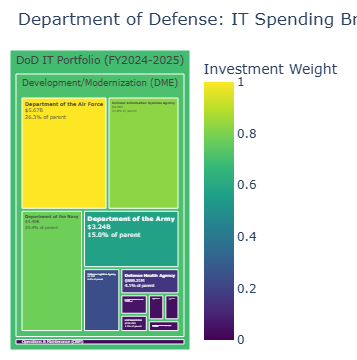

------------------------------
Step 3 Complete: All artifacts and formatted Viz generated.
Data saved to: it_spending_analysis_outputs/dod_it_cleaned_data.csv
Interactive Viz saved to: it_spending_analysis_outputs/dod_it_treemap_viz.html
------------------------------


In [7]:
# --- REPAIR LOGIC: Ensure the column exists ---
def format_spend(val):
    if val >= 1e9:
        return f"${val / 1e9:.2f}B"
    return f"${val / 1e6:.2f}M"

# Create the missing column that caused the ValueError
df['formatted_amount'] = df['total_spend'].apply(format_spend)
# ----------------------------------------------

# 1. Create the Interactive Treemap
fig = px.treemap(
    df, 
    path=[px.Constant("DoD IT Portfolio (FY2024-2025)"), 'it_category', 'sub_agency'], 
    values='total_spend',
    color='normalized_intensity',
    color_continuous_scale='Viridis',
    title='Department of Defense: IT Spending Breakdown by Sub-Agency',
    custom_data=['formatted_amount', 'normalized_intensity'], 
    labels={'normalized_intensity': 'Investment Weight', 'total_spend': 'Total Spend ($)'}
)

# 2. Logic: The "Exponent Killer"
fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{customdata[0]}<br>%{percentParent:.1%} of parent",
    hovertemplate="<b>%{label}</b><br>Spend: %{customdata[0]}<br>Weight: %{customdata[1]:.2f}<extra></extra>"
)

fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))

# Display the plot
fig.show()

# 3. Export Artifacts
output_dir = "it_spending_analysis_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df.to_csv(f"{output_dir}/dod_it_cleaned_data.csv", index=False)
fig.write_html(f"{output_dir}/dod_it_treemap_viz.html")

print("-" * 30)
print("Step 3 Complete: All artifacts and formatted Viz generated.")
print(f"Data saved to: {output_dir}/dod_it_cleaned_data.csv")
print(f"Interactive Viz saved to: {output_dir}/dod_it_treemap_viz.html")
print("-" * 30)

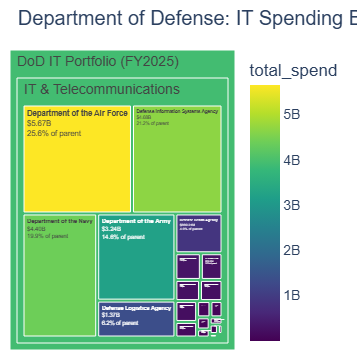

-----------------------------------
Project Complete: High-spec visualization generated.
Interactive Report saved to: it_spending_analysis_outputs/dod_it_spending_report.html
-----------------------------------


In [8]:
# --- Step 3: High-Spec Interactive Visualization ---

# 1. Create the Treemap
# Logic: We use 'total_spend' for box size calculation and 
# 'formatted_amount' for the human-readable text labels.
fig = px.treemap(
    df_cleaned, 
    path=[px.Constant("DoD IT Portfolio (FY2025)"), 'it_category', 'sub_agency'], 
    values='total_spend',
    color='total_spend',
    color_continuous_scale='Viridis',
    title='Department of Defense: IT Spending Breakdown by Sub-Agency',
    custom_data=['formatted_amount']
)

# 2. Logic: The UI Injector 
# This tells Plotly: "Ignore your default numbers; use my custom strings."
fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{customdata[0]}<br>%{percentParent:.1%} of parent",
    hovertemplate="<b>%{label}</b><br>Total Spend: %{customdata[0]}<extra></extra>"
)

# 3. Refine Layout for Professional Presentation
fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    font=dict(family="Arial", size=14),
    paper_bgcolor="white"
)

# 4. Display and Export
fig.show()

# Automated Artifact Export using your Global Config path
report_path = f"{OUTPUT_DIR}/dod_it_spending_report.html"
fig.write_html(report_path)

print("-" * 35)
print(f"Project Complete: High-spec visualization generated.")
print(f"Interactive Report saved to: {report_path}")
print("-" * 35)

## 4. Conclusion & Data Persistence

In this final phase, we transition from **Exploratory Data Analysis (EDA)** to **Artifact Generation**. As a best practice in reproducible research, we must ensure that our findings are both portable and verifiable.

### Data Governance & Export Strategy:
1. **Cleaned Dataset (`.csv`):** We export the processed DataFrame containing our calculated `it_category` and `normalized_intensity`. This allows for secondary analysis in PowerBI, Tableau, or Excel without re-running the ingestion pipeline.
2. **Interactive Asset (`.html`):** The Plotly Treemap is exported as a standalone HTML file. This preserves all D3.js interactivity (hover effects, drill-downs, and scaling) for deployment on a GitHub Pages site or a portfolio repository.
3. **Execution Summary:** We generate a high-level financial summary of the FY2025 DoD IT obligations to provide immediate context upon notebook completion.

**Next Steps:**
* Upload the `project_outputs/` folder to GitHub repository.
* Reference the `dod_it_spending_treemap.html` in `README.md` for a live demonstration.

In [9]:
# 1. Configuration: Unified Output Directory
output_dir = "it_spending_analysis_outputs"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. File Path Definitions
timestamp = time.strftime("%Y%m%d-%H%M")
csv_path = os.path.join(output_dir, "dod_it_cleaned_data.csv")
html_path = os.path.join(output_dir, "dod_it_treemap_viz.html")
archive_path = os.path.join(output_dir, f"dod_it_audit_{timestamp}.csv")

# 3. Export Execution
df.to_csv(csv_path, index=False)       # The "Latest" data for the repo
df.to_csv(archive_path, index=False)   # The "Timestamped" audit trail
fig.write_html(html_path)              # The Interactive Viz

# 4. Summary Statistics for the Console
print("-" * 40)
print("GOVERNMENT IT SPENDING: FINAL SUMMARY")
print("-" * 40)
print(f"Total Sub-Agencies Analyzed: {len(df)}")
print(f"Total DoD IT Spend (FY2024-25): ${df['total_spend'].sum():,.2f}")
print(f"Portfolio Median Spend:        ${df['total_spend'].median():,.2f}")
print("-" * 40)
print(f"Main Dataset:    {csv_path}")
print(f"Archive Audit:   {archive_path}")
print(f"Interactive Viz: {html_path}")
print("-" * 40)
print("Notebook execution complete. Ready for GitHub push.")

----------------------------------------
GOVERNMENT IT SPENDING: FINAL SUMMARY
----------------------------------------
Total Sub-Agencies Analyzed: 22
Total DoD IT Spend (FY2024-25): $22,128,158,188.14
Portfolio Median Spend:        $187,689,628.68
----------------------------------------
Main Dataset:    it_spending_analysis_outputs\dod_it_cleaned_data.csv
Archive Audit:   it_spending_analysis_outputs\dod_it_audit_20260322-2041.csv
Interactive Viz: it_spending_analysis_outputs\dod_it_treemap_viz.html
----------------------------------------
Notebook execution complete. Ready for GitHub push.
